In [1]:
import torch
from torch import nn
from torch.utils import data
import torchvision
from torchvision import  transforms

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=False)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=False)
batch_size = 256
train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True)
test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False)

In [4]:
class SoftmaxRegression(nn.Module):
  def __init__(self,in_features,out_features):
    super().__init__()
    self.linear=nn.Linear(in_features,out_features)
  def forward(self,x):
    x=x.reshape((-1,self.linear.in_features))
    out=self.linear(x)
    return out


In [5]:
def evalute_acc(model, data_iter):
  model.eval()
  acc_sum,n=0.0,0
  with torch.no_grad():
    for X, y in data_iter:
      X, y = X.to(device), y.to(device)
      y_hat=model(X)
      acc_sum+=(y_hat.argmax(dim=1)==y).sum().item()
      n+=y.shape[0]
  return acc_sum/n

def accuracy(y_hat, y):
    return (y_hat.argmax(dim=1) == y).float().sum().item()

In [6]:
print(iter(train_iter))

In [8]:
model=SoftmaxRegression(in_features=784, out_features=10)
model.to(device) 
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(), lr=0.1)
num_epochs=10
train_loss=[]
train_acc=[]
test_acc=[]
for epoch in range(num_epochs):
  model.train()
  loss_sum,acc_sum,n=0.0,0.0,0
  for X, y in train_iter:
    X, y = X.to(device), y.to(device)
    y_hat=model(X)
    l=criterion(y_hat, y)
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    loss_sum+=l.item()*y.shape[0]
    acc_sum+=accuracy(y_hat,y)
    n+=y.shape[0]
  train_loss.append(loss_sum/n)
  train_acc.append(acc_sum/n)
  test_acc.append(evalute_acc(model,test_iter))
  print(f'epoch {epoch + 1}, train loss {loss_sum/n:.6f}, test acc {test_acc[-1]:.6f}')

epoch 1, train loss 0.787663, test acc 0.779900
epoch 2, train loss 0.570994, test acc 0.798700
epoch 3, train loss 0.526495, test acc 0.805900
epoch 4, train loss 0.501263, test acc 0.824100
epoch 5, train loss 0.485813, test acc 0.812000
epoch 6, train loss 0.474082, test acc 0.825100
epoch 7, train loss 0.465829, test acc 0.830800
epoch 8, train loss 0.458256, test acc 0.801400
epoch 9, train loss 0.452759, test acc 0.821700
epoch 10, train loss 0.446838, test acc 0.834600


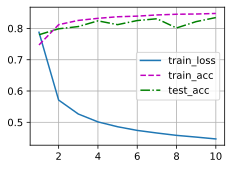

In [18]:
%matplotlib inline
import sys
sys.path.append('../')
from tools.PLOT import plot
# train_loss=[] train_acc=[] test_acc=[]
import numpy as np
# X 为3行len（train_loss）列的矩阵
x=np.arange(1,1+len(train_loss))
X=[x,x,x]
Y = np.array([train_loss, train_acc, test_acc])
plot(X,Y,legend=['train_loss', 'train_acc', 'test_acc'])
